# EvalTree Win-Rate Node Consistency Analysis

For each node in the EvalTree, compute a **win rate** for the stronger model (defined as the model with higher raw accuracy on the full benchmark). The win rate at a node is the fraction of instances that model A got correct **and** model B got wrong. Then compute a **consistency score** across all nodes to measure how well the tree clustering separates model capabilities.

## Setup

Set BENCHMARK to one of: **MATH**, **MMLU**, **DS-1000**.
Uncomment the appropriate MODELS line to choose which pair to compare.

In [1]:
import json
import os
import sys

import matplotlib.pyplot as plt
import numpy as np

REPO_ROOT = os.path.dirname(os.getcwd())
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)
if os.getcwd() not in sys.path:
    sys.path.insert(0, os.getcwd())

from intra_config import (
    DEFAULT_SPLIT,
    confidence_interval_path,
    results_json_path,
)

BENCHMARK_SPLITS = {
    "MATH": "full",
    "MMLU": "10042-4000",
    "DS-1000": "600-400",
}

# --- Choose benchmark and models ---
BENCHMARK = "MATH"
MODELS = ["Llama-3.1-8B-Instruct", "gpt-4o-mini-2024-07-18"]
# MODELS = ["Llama-3.1-8B-Instruct", "dart-math-llama3-8b-uniform"]
# MODELS = ["gpt-4o-mini-2024-07-18", "dart-math-llama3-8b-uniform"]

SPLIT = BENCHMARK_SPLITS.get(BENCHMARK, DEFAULT_SPLIT)
EVALTREE_ROOT = os.path.join(REPO_ROOT, "Datasets")

MIN_NODES = 2  # minimum instances per node to include

print(f"Benchmark={BENCHMARK}, split={SPLIT}")
print(f"Models: {MODELS}")

Benchmark=MATH, split=full
Models: ['Llama-3.1-8B-Instruct', 'gpt-4o-mini-2024-07-18']


## Load Data

Load the confidence-interval tree (for node structure / instance lists) and the per-instance binary results for each model.

In [2]:
def load_ci_tree(benchmark, model, split, evaltree_root):
    path = confidence_interval_path(benchmark, model, split=split, evaltree_root=evaltree_root)
    if not os.path.isfile(path):
        raise FileNotFoundError(path)
    with open(path) as f:
        return json.load(f)


def load_results_list(path):
    """Load results.json as a list of 0/1 (index = instance id)."""
    with open(path) as f:
        data = json.load(f)
    if isinstance(data, list):
        return data
    n = max(int(k) for k in data) + 1
    out = [0] * n
    for k, v in data.items():
        out[int(k)] = v
    return out


ci_trees = {m: load_ci_tree(BENCHMARK, m, SPLIT, EVALTREE_ROOT) for m in MODELS}

results = {}
for m in MODELS:
    rpath = results_json_path(BENCHMARK, m, evaltree_root=EVALTREE_ROOT)
    if not os.path.isfile(rpath):
        raise FileNotFoundError(rpath)
    results[m] = load_results_list(rpath)

print(f"Loaded results: {{{', '.join(f'{m}: {len(results[m])} instances' for m in MODELS)}}}")

Loaded results: {Llama-3.1-8B-Instruct: 5000 instances, gpt-4o-mini-2024-07-18: 5000 instances}


## Benchmark-Level Answer Breakdown

Before diving into per-node analysis, count the four mutually exclusive outcomes across all instances on the full benchmark.

In [3]:
n_instances = min(len(results[MODELS[0]]), len(results[MODELS[1]]))

r0 = np.array(results[MODELS[0]][:n_instances], dtype=int)
r1 = np.array(results[MODELS[1]][:n_instances], dtype=int)

both_right  = int(np.sum((r0 == 1) & (r1 == 1)))
both_wrong  = int(np.sum((r0 == 0) & (r1 == 0)))
only_m0     = int(np.sum((r0 == 1) & (r1 == 0)))
only_m1     = int(np.sum((r0 == 0) & (r1 == 1)))

print(f"Total instances: {n_instances}")
print(f"  Both correct:              {both_right:5d}  ({both_right/n_instances:.2%})")
print(f"  Both wrong:                {both_wrong:5d}  ({both_wrong/n_instances:.2%})")
print(f"  Only {MODELS[0]:>40s} correct: {only_m0:5d}  ({only_m0/n_instances:.2%})")
print(f"  Only {MODELS[1]:>40s} correct: {only_m1:5d}  ({only_m1/n_instances:.2%})")

Total instances: 5000
  Both correct:               2281  (45.62%)
  Both wrong:                 1293  (25.86%)
  Only                    Llama-3.1-8B-Instruct correct:   203  (4.06%)
  Only                   gpt-4o-mini-2024-07-18 correct:  1223  (24.46%)


## Determine the Stronger Model (Model A)

Model A is the model with **higher raw accuracy on the full benchmark**.

In [4]:
total_acc = {}
for m in MODELS:
    root = ci_trees[m]
    s, n = root.get("sum_metrics"), root.get("size")
    total_acc[m] = (s / n) if n and n > 0 else 0.0

if total_acc[MODELS[0]] >= total_acc[MODELS[1]]:
    MODEL_A, MODEL_B = MODELS[0], MODELS[1]
else:
    MODEL_A, MODEL_B = MODELS[1], MODELS[0]

print(f"Model A (stronger): {MODEL_A}  ({total_acc[MODEL_A]:.2%})")
print(f"Model B (weaker):   {MODEL_B}  ({total_acc[MODEL_B]:.2%})")

Model A (stronger): gpt-4o-mini-2024-07-18  (70.08%)
Model B (weaker):   Llama-3.1-8B-Instruct  (49.68%)


## Collect Nodes and Compute Win Rates

For each eligible node, the **win rate** is:

$$\text{win\_rate}(\text{node}) = \frac{|\{i \in \text{node} : A_i = 1 \land B_i = 0\}|}{|\text{node}|}$$

i.e. the fraction of the node's instances that model A answered correctly and model B did not.

In [5]:
def collect_all_nodes_with_path(ci_node, path, out):
    """Traverse CI tree. Append (path, instance_list) for every internal node."""
    st = ci_node.get("subtrees")
    if st is None:
        return []
    if isinstance(st, int):
        return [st]
    if isinstance(st, list):
        instances = []
        for sub in st:
            instances.extend(collect_all_nodes_with_path(sub, path, out))
        out.append((path, instances))
        return instances
    if isinstance(st, dict):
        all_instances = []
        for k, sub in st.items():
            all_instances.extend(collect_all_nodes_with_path(sub, path + [str(k)], out))
        if path:  # skip root
            out.append((path, all_instances))
        return all_instances
    return []


all_nodes = []
collect_all_nodes_with_path(ci_trees[MODELS[0]], [], all_nodes)
all_nodes = [(p, inst) for p, inst in all_nodes if len(inst) >= MIN_NODES]

res_a = results[MODEL_A]
res_b = results[MODEL_B]

win_rates = []   # one per node
node_sizes = []  # number of instances per node

for path, instances in all_nodes:
    n = len(instances)
    wins = 0
    for idx in instances:
        a_correct = res_a[idx] if idx < len(res_a) else 0
        b_correct = res_b[idx] if idx < len(res_b) else 0
        if a_correct and not b_correct:
            wins += 1
    wr = wins / n
    win_rates.append(wr)
    node_sizes.append(n)

win_rates = np.array(win_rates)
node_sizes = np.array(node_sizes)

print(f"Eligible nodes: {len(win_rates)}")
print(f"Win-rate stats:  min={win_rates.min():.4f}  max={win_rates.max():.4f}  "
      f"mean={win_rates.mean():.4f}  median={np.median(win_rates):.4f}")

Eligible nodes: 2962
Win-rate stats:  min=0.0000  max=1.0000  mean=0.2411  median=0.2000


## Consistency Score

Per-node consistency (0 = win rate at 0.5, i.e. no differentiation; 1 = win rate at 0 or 1, i.e. perfect differentiation):

$$c_i = 2\,|\text{win\_rate}_i - 0.5|$$

Overall consistency score (mean across nodes):

$$\text{consistency} = \frac{1}{N}\sum_{i=1}^{N} c_i$$

A higher score means the clustering better isolates nodes where model A clearly outperforms (or underperforms) model B.

In [6]:
per_node_consistency = 2 * np.abs(win_rates - 0.5)  # 0‒1 scale
consistency_score = np.mean(per_node_consistency)

print(f"Consistency score (mean per-node): {consistency_score:.4f}")
print(f"  (over {len(win_rates)} nodes)")
print(f"  Per-node stats:  min={per_node_consistency.min():.4f}  "
      f"max={per_node_consistency.max():.4f}  "
      f"median={np.median(per_node_consistency):.4f}")

Consistency score (mean per-node): 0.6175
  (over 2962 nodes)
  Per-node stats:  min=0.0000  max=1.0000  median=0.6667


## Win-Rate Histogram

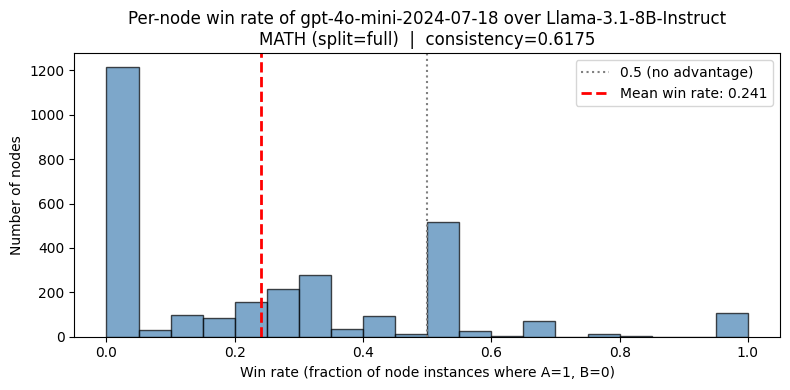

In [7]:
fig, ax = plt.subplots(figsize=(8, 4))
bins = np.linspace(0, 1, 21)
ax.hist(win_rates, bins=bins, edgecolor="black", alpha=0.7, color="steelblue")
ax.axvline(0.5, color="gray", linestyle=":", linewidth=1.5, label="0.5 (no advantage)")
ax.axvline(win_rates.mean(), color="red", linestyle="--", linewidth=2,
           label=f"Mean win rate: {win_rates.mean():.3f}")
ax.set_xlabel("Win rate (fraction of node instances where A=1, B=0)")
ax.set_ylabel("Number of nodes")
ax.set_title(
    f"Per-node win rate of {MODEL_A} over {MODEL_B}\n"
    f"{BENCHMARK} (split={SPLIT})  |  consistency={consistency_score:.4f}"
)
ax.legend()
plt.tight_layout()
plt.show()

## Win Rate vs. Node Size (scatter)

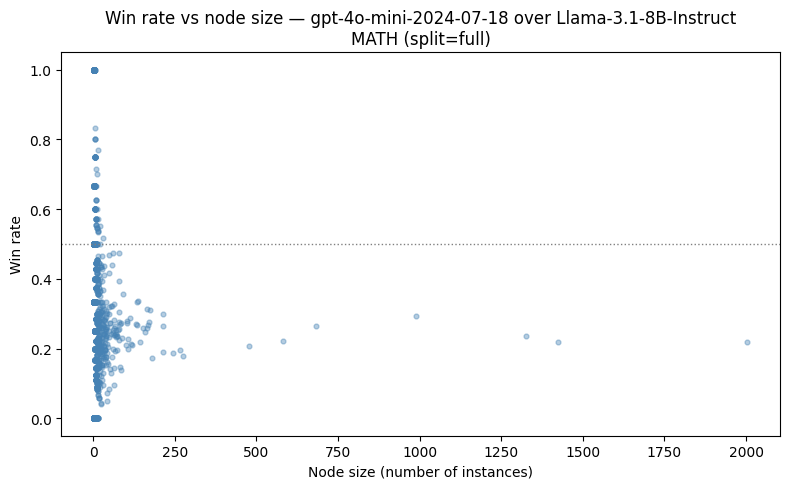

In [8]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(node_sizes, win_rates, alpha=0.4, s=12, color="steelblue")
ax.axhline(0.5, color="gray", linestyle=":", linewidth=1)
ax.set_xlabel("Node size (number of instances)")
ax.set_ylabel("Win rate")
ax.set_title(
    f"Win rate vs node size — {MODEL_A} over {MODEL_B}\n"
    f"{BENCHMARK} (split={SPLIT})"
)
plt.tight_layout()
plt.show()

## Per-Node Consistency Histogram

Distribution of $c_i = 2\,|\text{win\_rate}_i - 0.5|$ (0 = no differentiation, 1 = perfect differentiation).

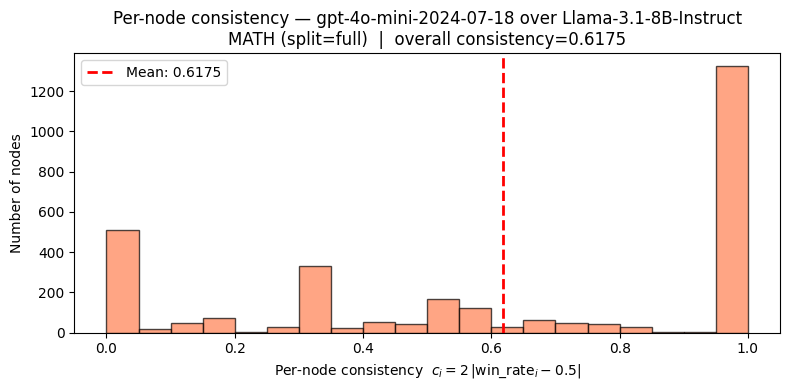

In [9]:
fig, ax = plt.subplots(figsize=(8, 4))
bins_dev = np.linspace(0, 1, 21)
ax.hist(per_node_consistency, bins=bins_dev, edgecolor="black", alpha=0.7, color="coral")
ax.axvline(consistency_score, color="red", linestyle="--", linewidth=2,
           label=f"Mean: {consistency_score:.4f}")
ax.set_xlabel("Per-node consistency  $c_i = 2\\,|\\mathrm{win\\_rate}_i - 0.5|$")
ax.set_ylabel("Number of nodes")
ax.set_title(
    f"Per-node consistency — {MODEL_A} over {MODEL_B}\n"
    f"{BENCHMARK} (split={SPLIT})  |  overall consistency={consistency_score:.4f}"
)
ax.legend()
plt.tight_layout()
plt.show()